# SUA spatial distibution of different types of units in cortical space

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params = yaml.safe_load(f)

DATA_FOLDER = params['data_folder']  # folder with all the preprocessed data
DATES = params['dates']

DF_FOLDER = '/CSNG/studekat/ripple_band_project/dataframes'  # original version of the dataframes loading 
MONKEY_LIST = ['L','N','F']
AREAS_MERGED = params['areas_merged']
FINAL_CLASSES = params['final_classes']
COLORS_CLASSES = params['colors_class']

In [4]:
L_coors =np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [5]:
N_coors =np.array([[1,4],[2,3],[2,4],[1,5],  # row, col, the first 4 arrays
           [2,5],[1,6],[2,7],[1,7],
           [1,2],[1,3],[0,4],[0,3],
           [0,2],[1,1],[0,1],[0,0]])

In [6]:
F_coors = np.array([[1,9],[0,9],[1,8],[0,8],  # row, col, the first 4 arrays
           [1,7],[0,7],[1,6],[1,5],
           [0,0],[0,1],[1,1],[0,2],
           [1,2],[0,3],[0,4],[0,5]])

In [7]:
A_coors = np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [8]:
arrays_coors = {'A':A_coors,
              'L':L_coors,
              'N':N_coors,
              'F':F_coors,}
n_rows_dict = {'A':4,
              'L':4,
              'N':3,
              'F':2,}
n_cols_dict = {'A':8,
              'L':8,
              'N':8,
              'F':10,}

## Plotting

(436, 109)
(429, 109)



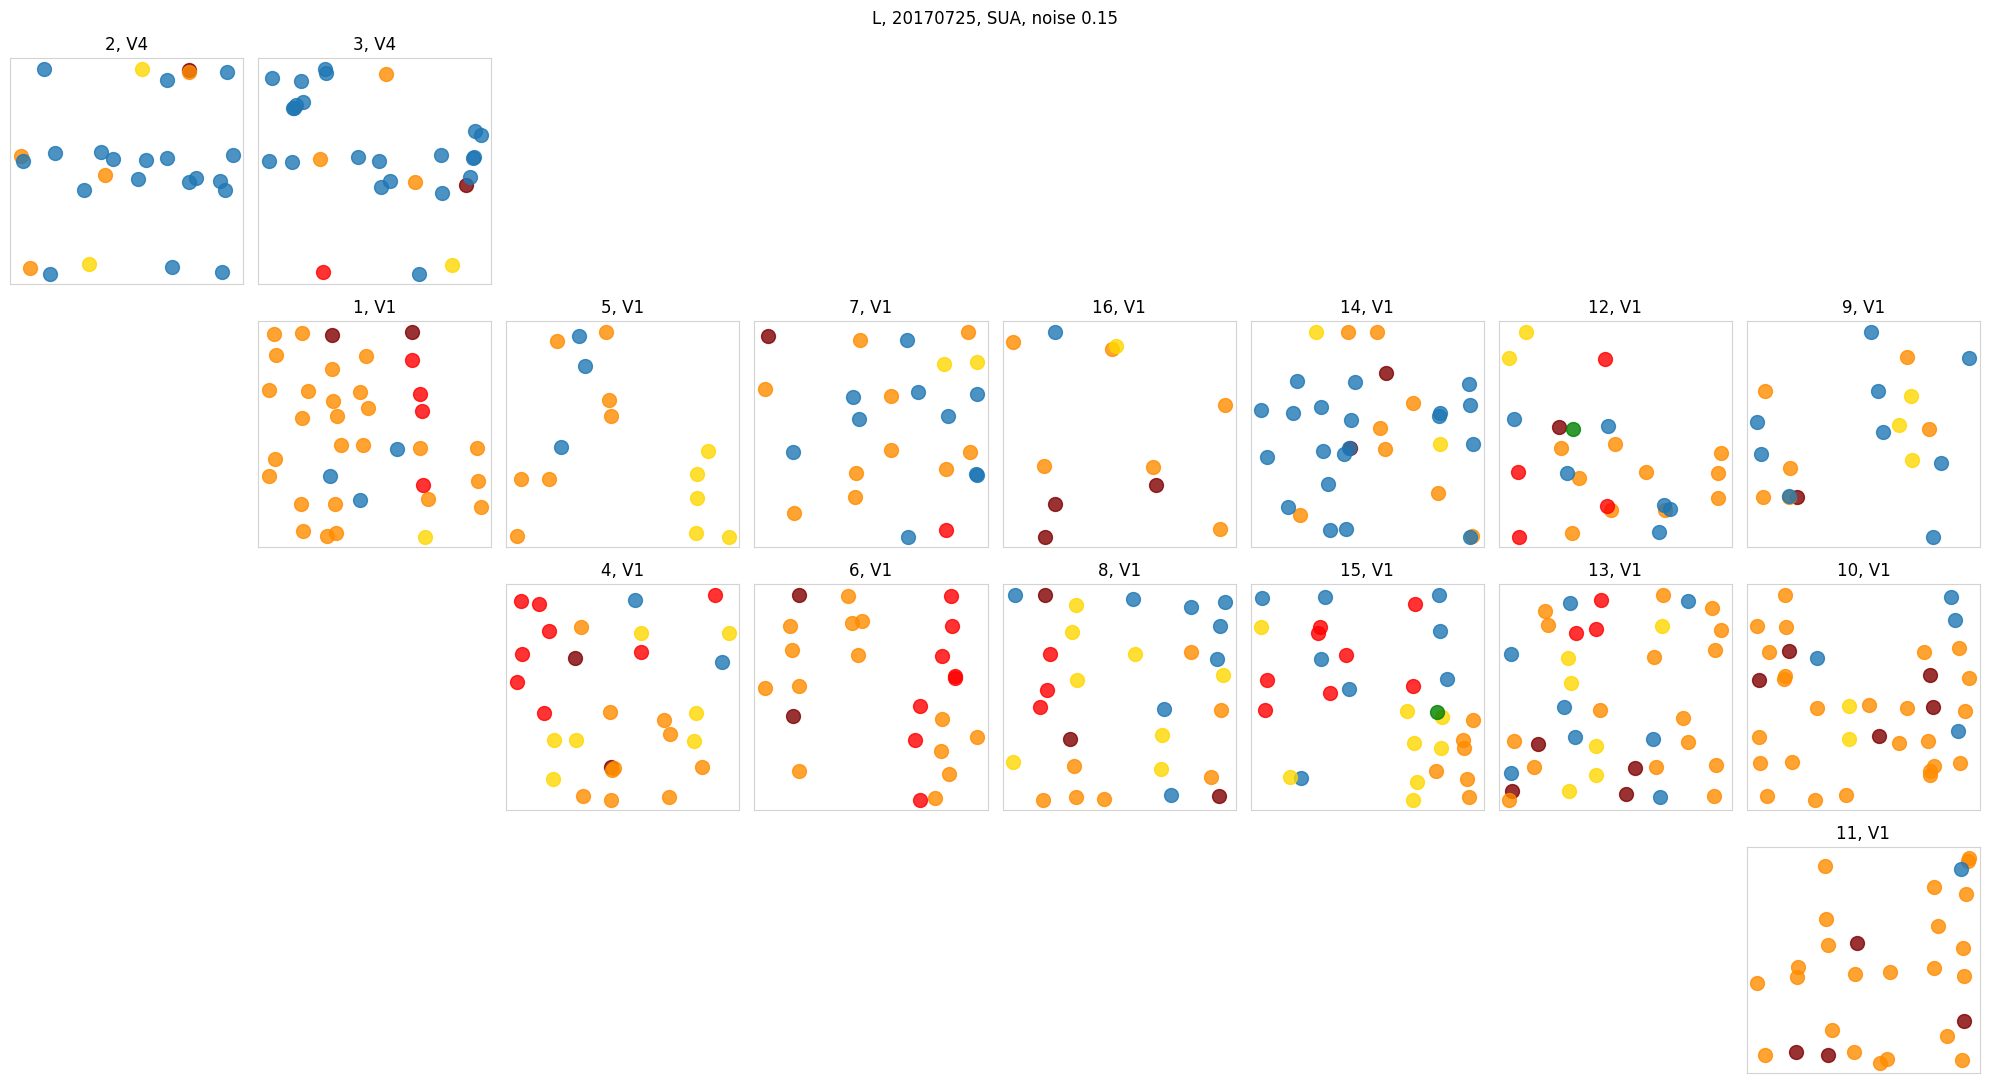

(480, 109)
(479, 109)



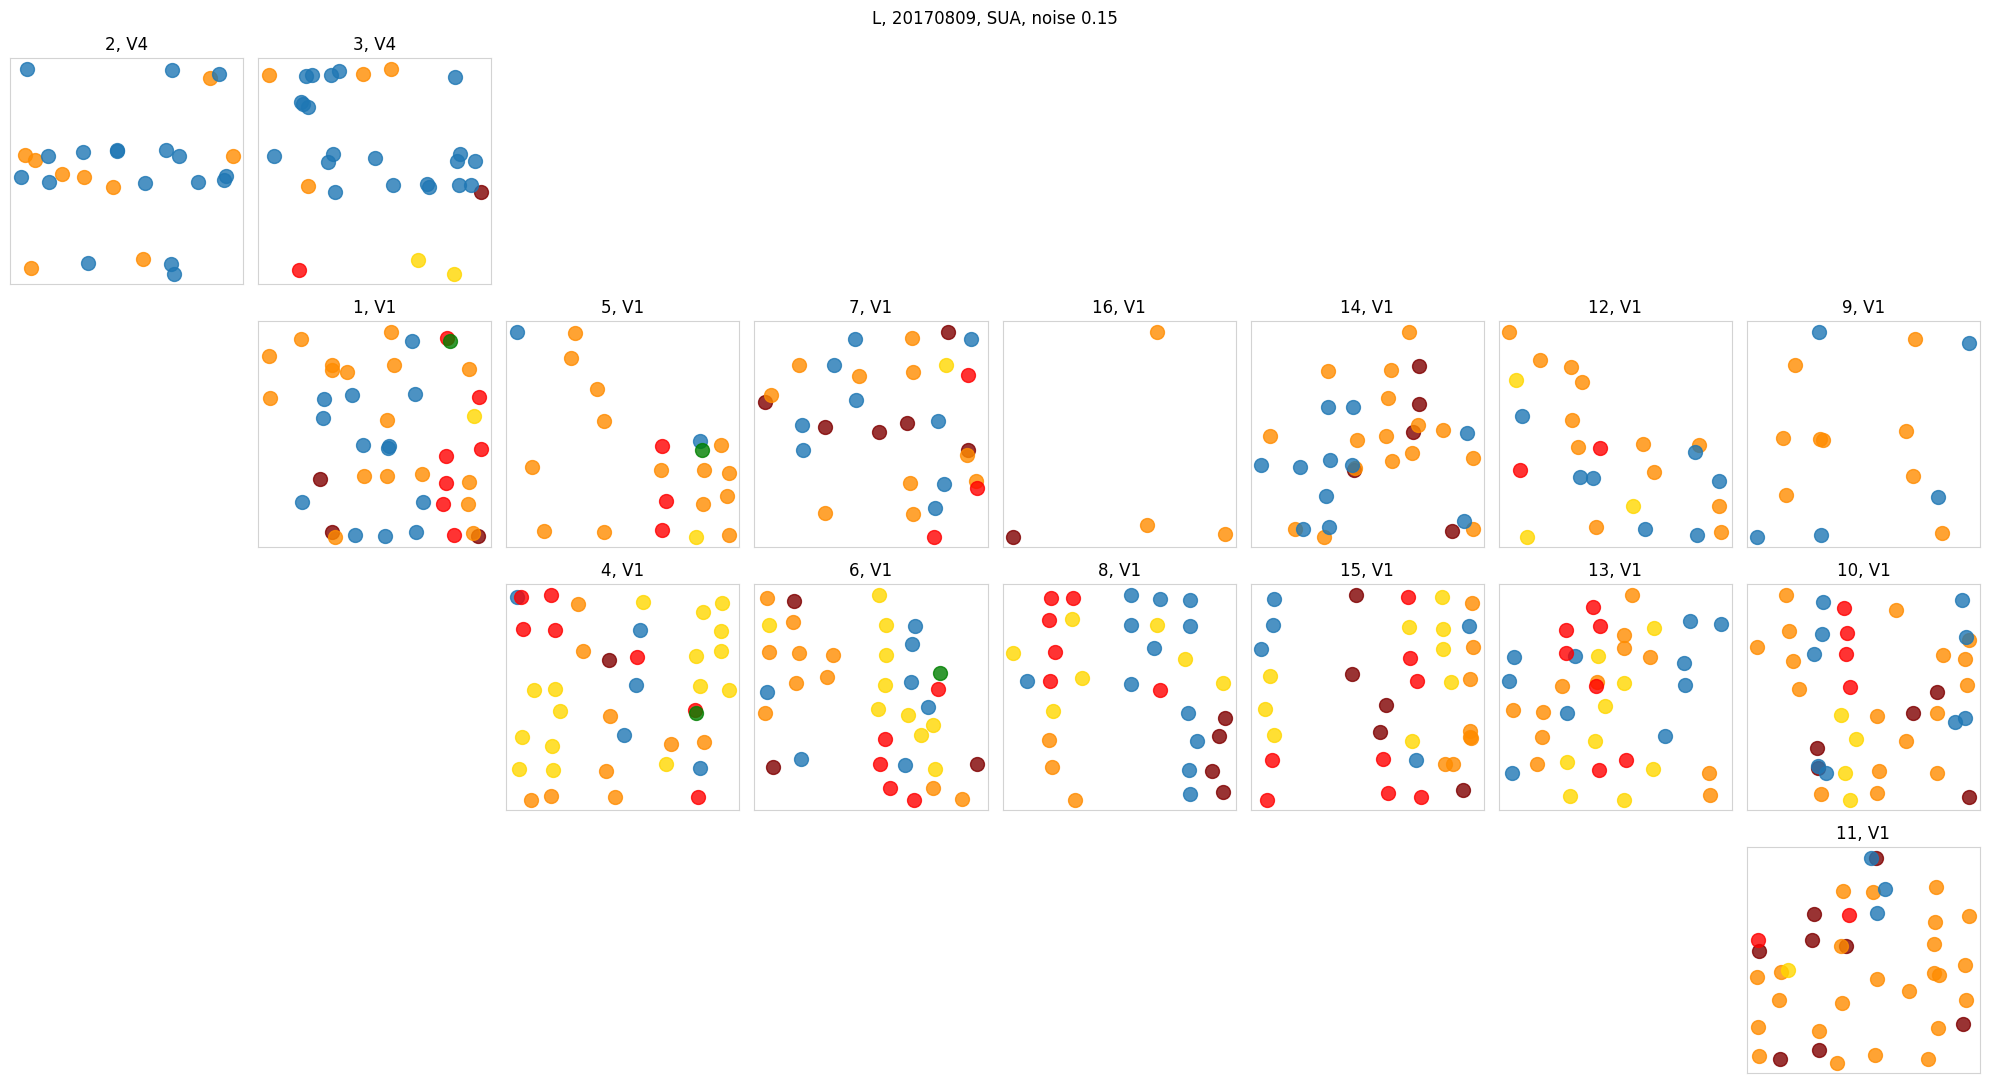

(405, 109)
(404, 109)



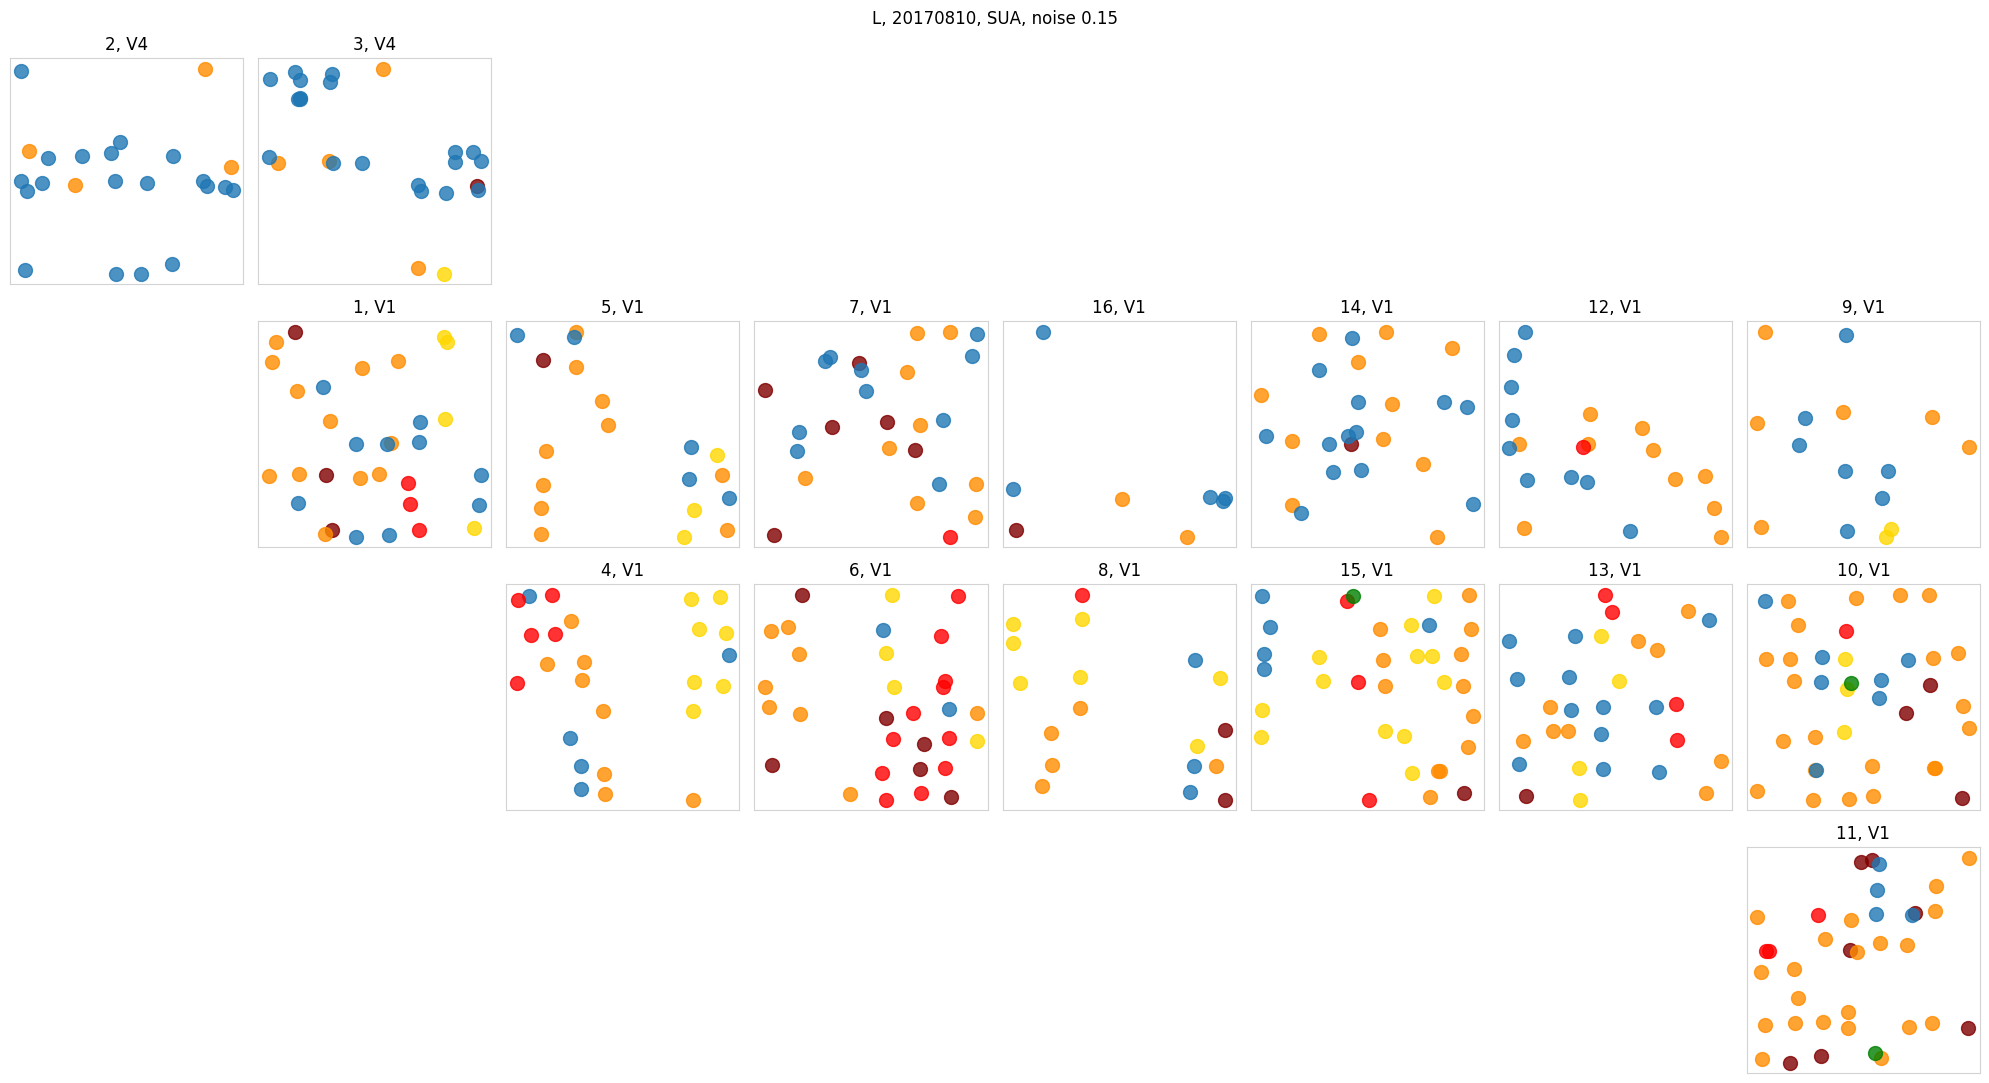

(351, 109)
(351, 109)



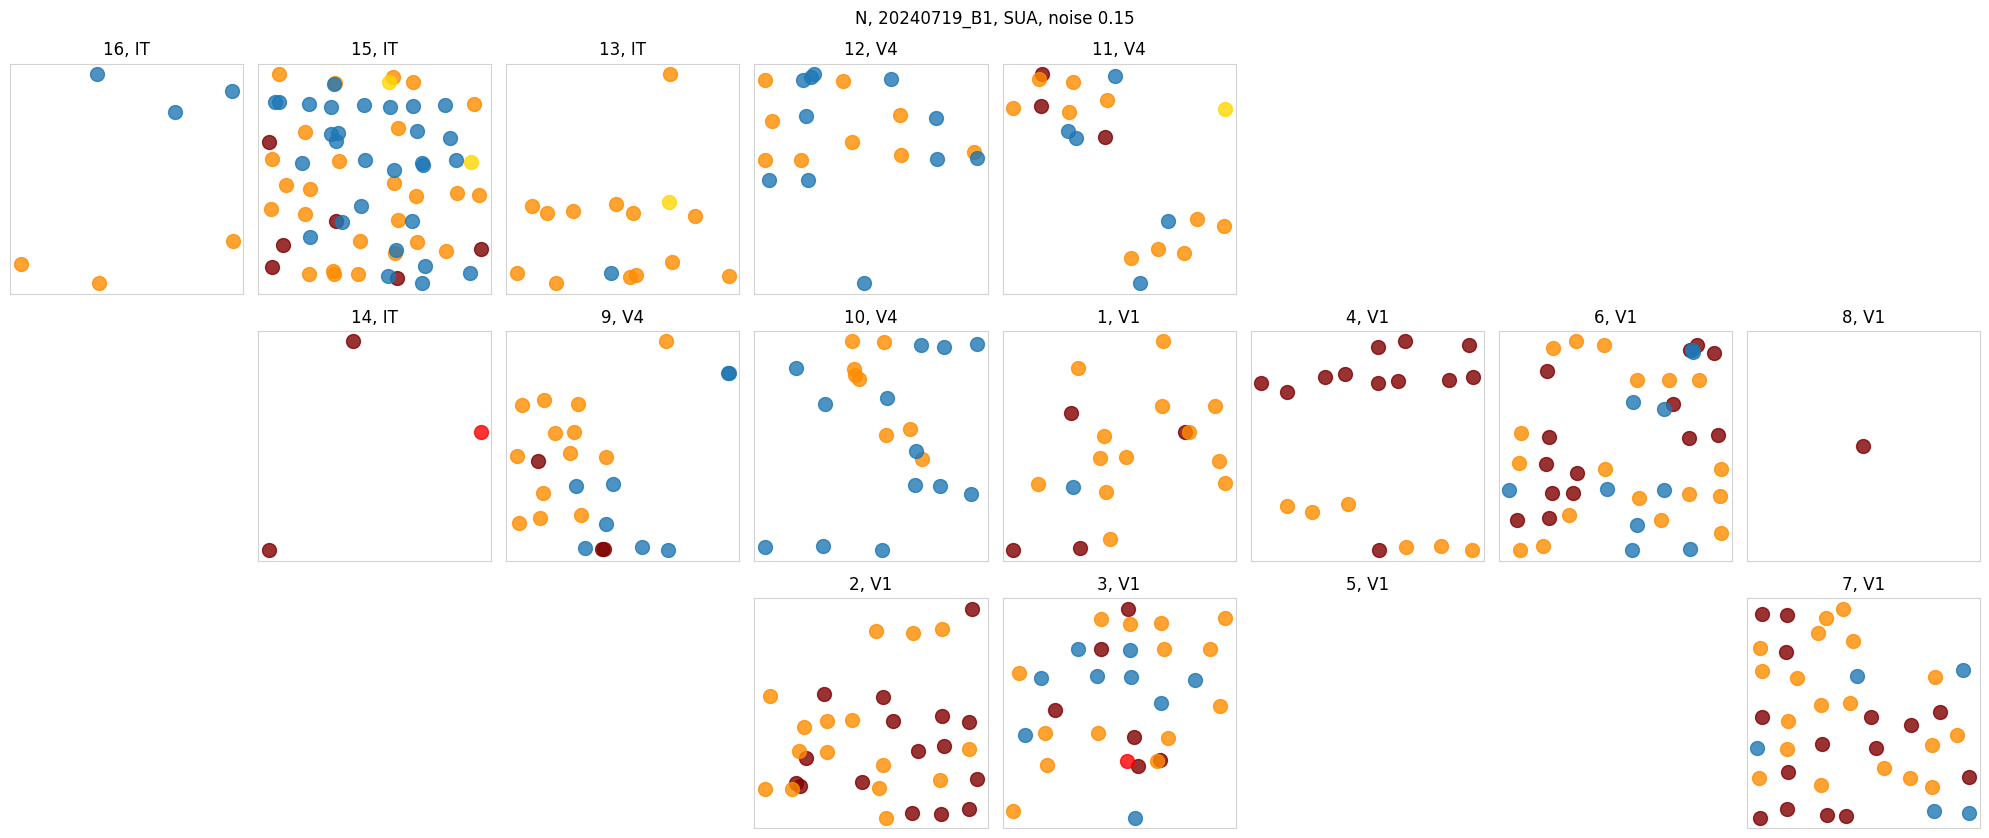

(358, 109)
(358, 109)



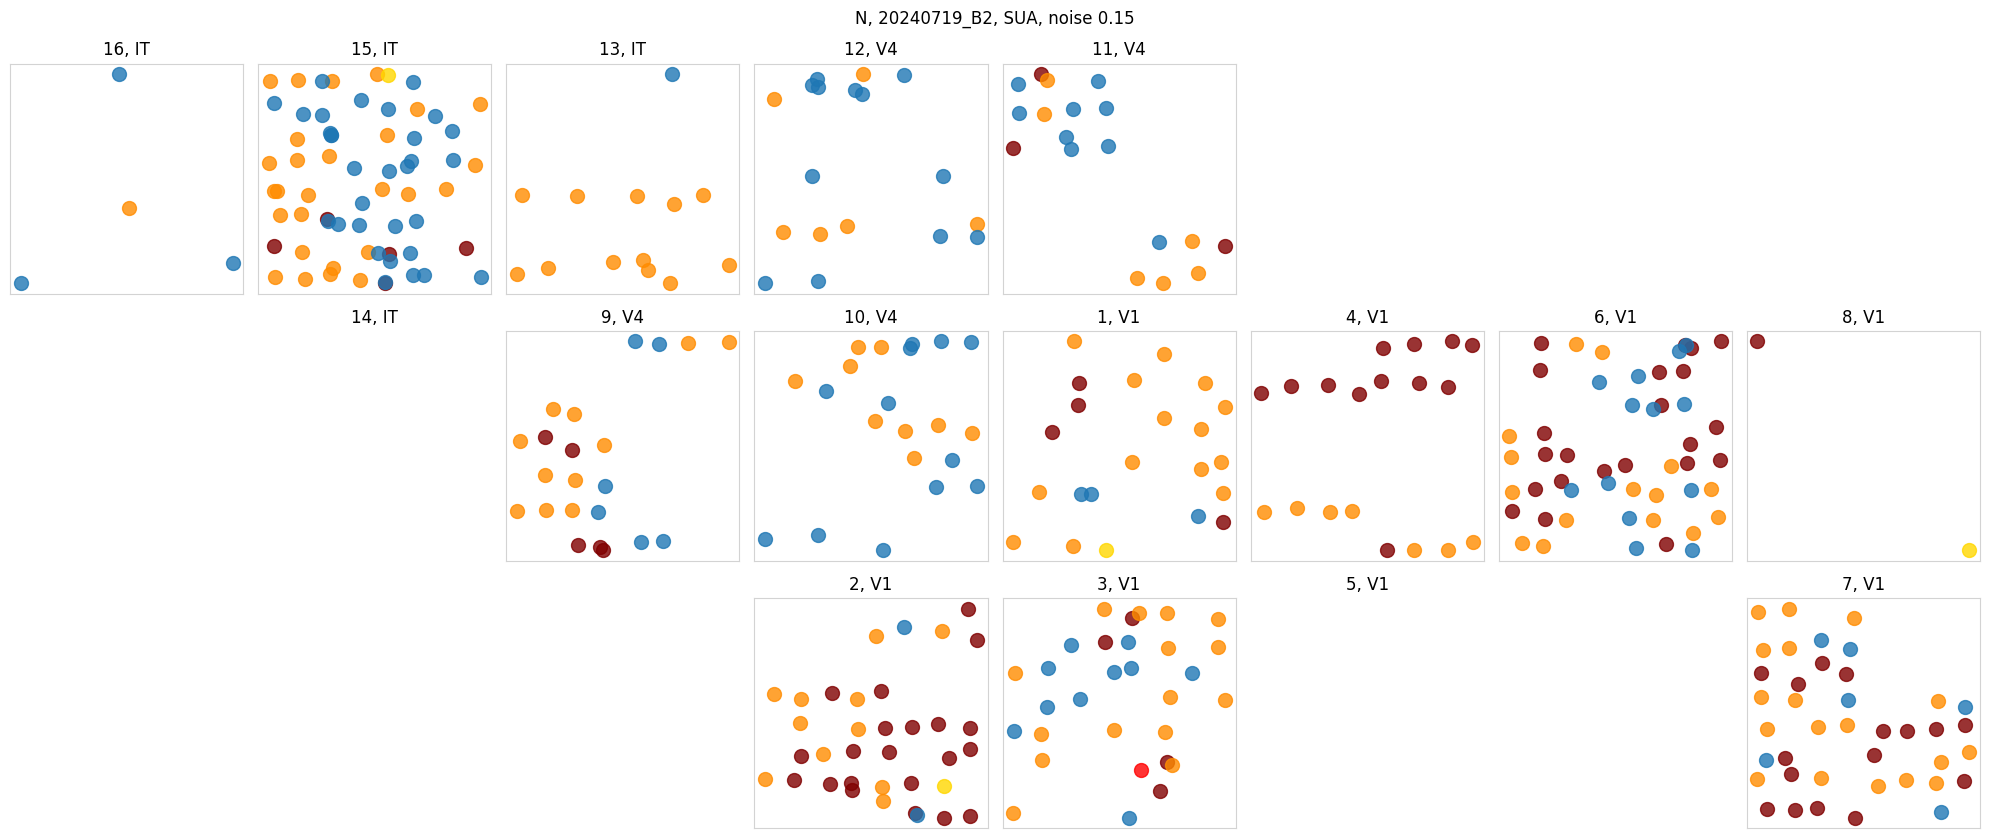

(680, 109)
(680, 109)



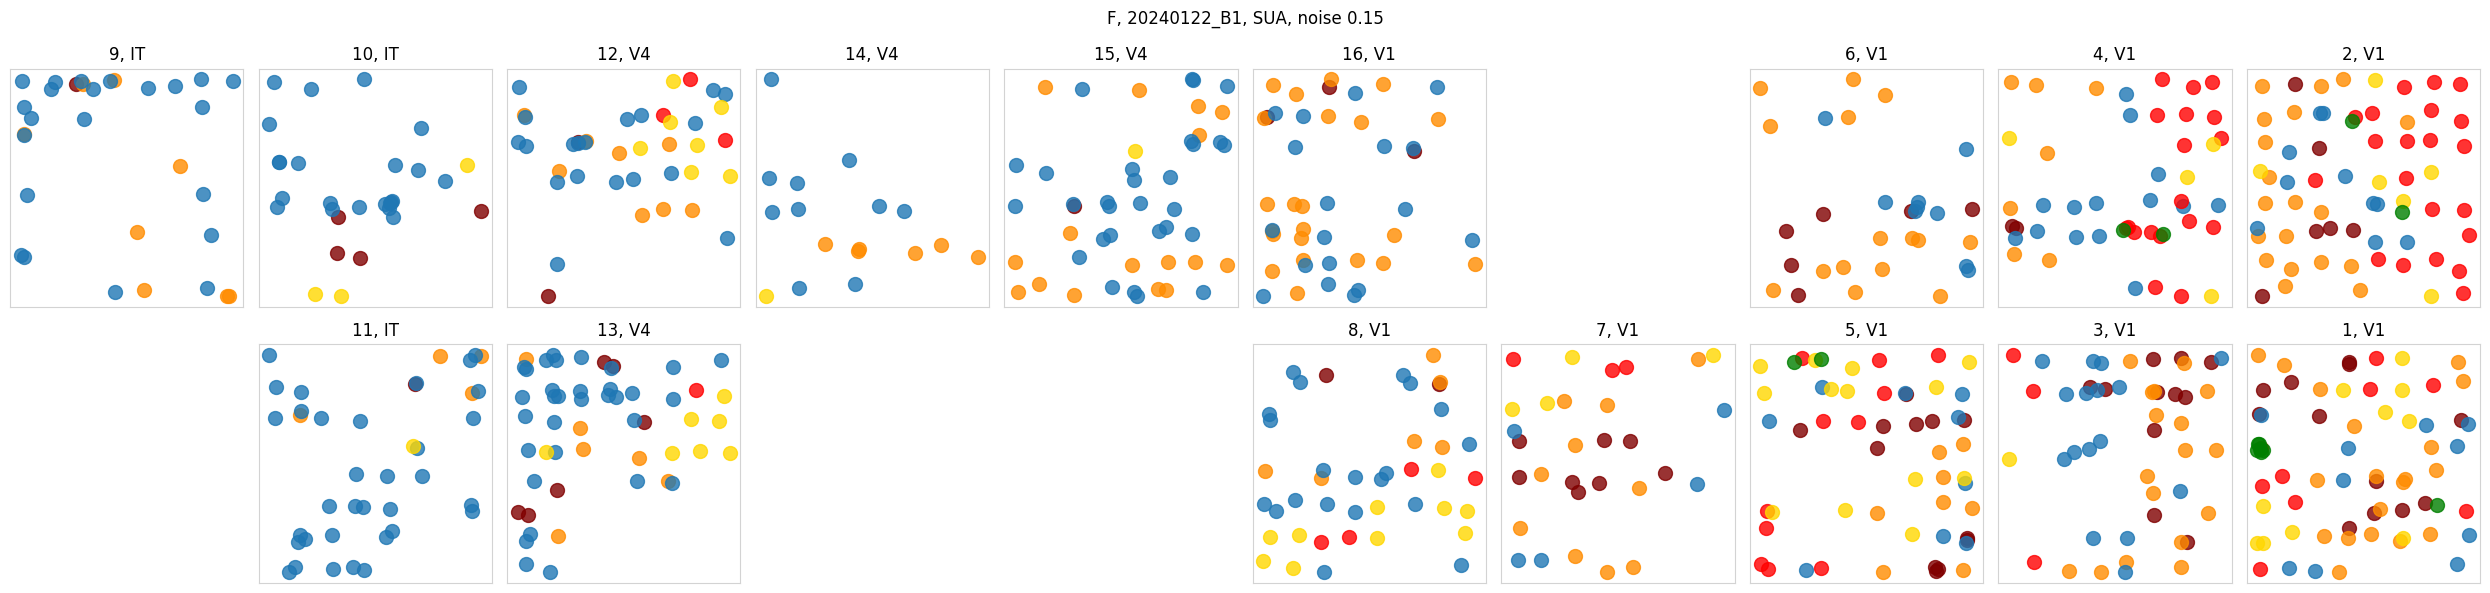

(295, 109)
(214, 109)



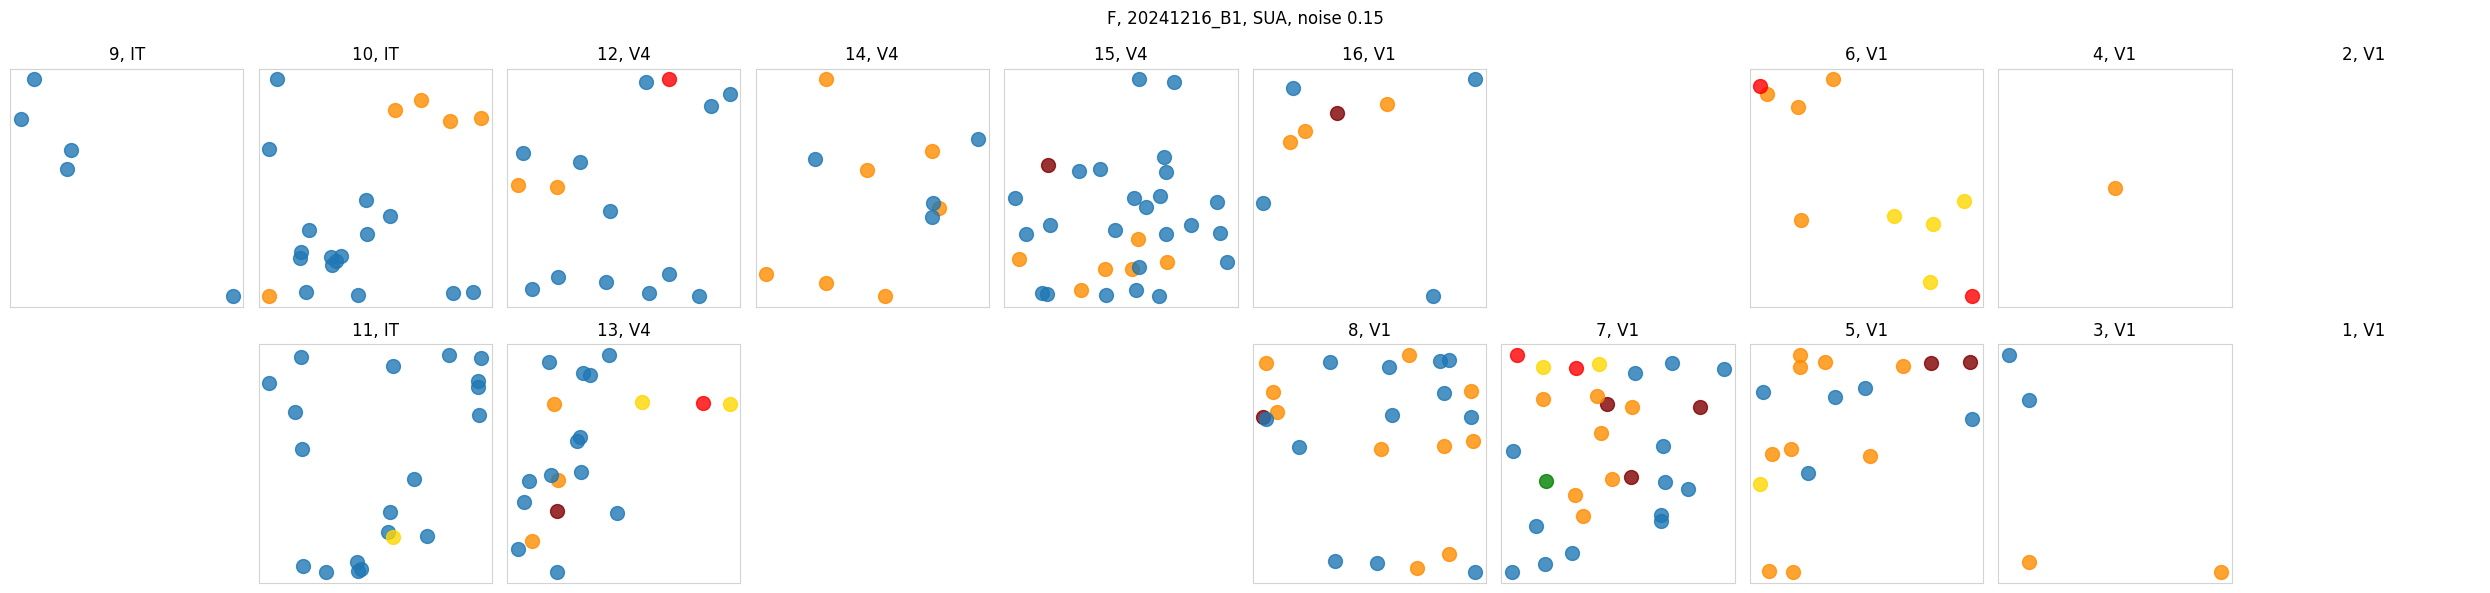

In [10]:
noise_level = 0.15

for monkey in MONKEY_LIST:
    layout = np.array(params['layout'][monkey])
    for date in params['dates'][monkey]['RS']:
        with open(f'{DF_FOLDER}/sua_prop_all/monkey{monkey}_all_arrays_date_{date}.pkl', "rb") as file:
            df_prop = pickle.load(file)
        #print(df_prop.shape)
        df_prop = df_prop[~df_prop['ch_is_noisy_120Hz']]
        df_prop = df_prop[~df_prop['ch_is_noisy_100Hz']]
        #print(df_prop.shape)
        #print()

        arr_dict = {arr:{} for arr in range(1,17)}
        for array in range(1,17):
            df_arr = df_prop[df_prop['array']==array]
            for cl in FINAL_CLASSES:
                arr_dict[array][cl] = []
            for cell_idx in df_arr.index:
                df_cell = df_arr.loc[cell_idx]
                cell_class = df_cell['final_class']
                cell_ch = df_cell['channel_order']
                layout_idx = np.where(layout==cell_ch)
                layout_idx = np.array([layout_idx[0][0], layout_idx[1][0]]) # reformating from array of arrays to array of two integer coors.
                arr_dict[array][cell_class].append(layout_idx)

        n_rows = n_rows_dict[monkey]
        n_cols = n_cols_dict[monkey]
        fig, ax = plt.subplots(n_rows,n_cols)
        fig.set_figwidth(2.5*n_cols)
        fig.set_figheight(2.5*n_rows+1)
        
        plt.suptitle(f'{monkey}, {date}, SUA, noise {noise_level}')
        
        for r in range(n_rows):
            for c in range(n_cols):
                ax[r,c].set_xticks([])
                ax[r,c].set_yticks([])
                for spine in ax[r,c].spines.values():
                    spine.set_color('white')
        
        for array in range(1,17):
            area = params['areas'][monkey][array-1]
            arr_coors_all_cl = arr_dict[array]  # dict. with coordinates of all SUA
            row_plot = arrays_coors[monkey][array-1][0]
            col_plot = arrays_coors[monkey][array-1][1]
            ax[row_plot,col_plot].set_title(f'{array}, {area}')
            for cl in FINAL_CLASSES:
                color = COLORS_CLASSES[cl]
                coors_cl = arr_coors_all_cl[cl]
                for coor in coors_cl:
                    row = coor[0]
                    col = coor[1]
                    row_noisy = row + np.random.normal(0, noise_level)
                    col_noisy = col + np.random.normal(0, noise_level)
                    ax[row_plot,col_plot].scatter(row_noisy,col_noisy,c=color,alpha=0.8,s=100)
                    for spine in ax[row_plot,col_plot].spines.values():
                        spine.set_color('lightgray')
            
        plt.tight_layout()
        plt.show()
        plt.close()